# California Housing - Classification Assignment

For this assignment I converted the **California Housing** dataset (which is normally used for regression) into a **binary classification** problem.

The task is to predict whether a house is **expensive** (price above the median) or **affordable** (price below the median). This notebook includes exploratory analysis, handling missing values, encoding the categorical column, feature scaling, training multiple classifiers and tuning the best model.



## About the Dataset

- The dataset contains **20640 rows** and **10 columns**.
- `ocean_proximity` is a categorical column which will need encoding.
- `median_house_value` will be used to create the target variable `price_category`.
- `total_bedrooms` has some missing values.



## 1. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_style('darkgrid')


## 2. Loading the Dataset

In [2]:
df = pd.read_csv('housing.csv')
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Basic Information about the Dataset

In [3]:
print('Shape of dataset:', df.shape)
df.info()


Shape of dataset: (20640, 10)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


## 4. Handling Missing Values

In [5]:
df.isnull().sum()


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Only `total_bedrooms` has 207 missing values. I will replace them with the median of the column because median is robust to outliers.

In [6]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
print('Missing values after imputation:', df.isnull().sum().sum())


Missing values after imputation: 0


## 5. Creating the Target Variable

Since this is a classification assignment, I converted `median_house_value` into a binary target. If the price is greater than or equal to the median price of the whole dataset, the house is labelled `1` (Expensive), otherwise `0` (Affordable).

In [7]:
median_price = df['median_house_value'].median()
print('Median house value:', median_price)

df['price_category'] = np.where(df['median_house_value'] >= median_price, 1, 0)
df['price_category'].value_counts()


Median house value: 179700.0


price_category
1    10325
0    10315
Name: count, dtype: int64

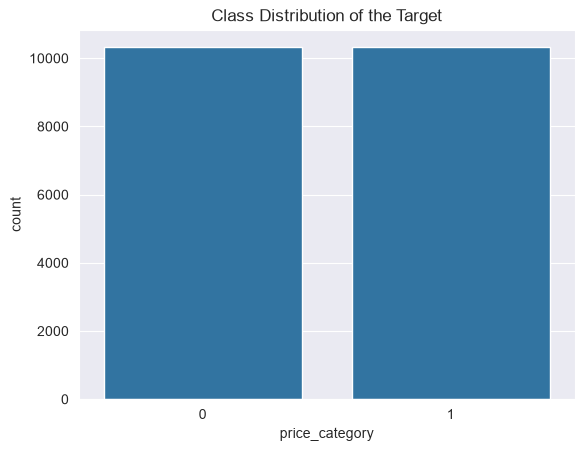

In [8]:
sns.countplot(data=df, x='price_category')
plt.title('Class Distribution of the Target')
plt.show()


The classes are **almost perfectly balanced** (50 / 50), so we do not need any balancing technique like SMOTE for this dataset.

## 6. Exploring the Categorical Column

In [9]:
df['ocean_proximity'].value_counts()


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

## 7. Encoding the Categorical Column

Machine learning models cannot understand text, so I converted `ocean_proximity` into dummy variables using one-hot encoding. I used `drop_first=True` to avoid the dummy variable trap (multicollinearity).

In [10]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,price_category,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,1,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,1,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,1,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,1,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,1,False,False,True,False


## 8. Correlation Between Features

Let me check the correlation matrix. `median_income` is expected to be the strongest feature for predicting the house price category.

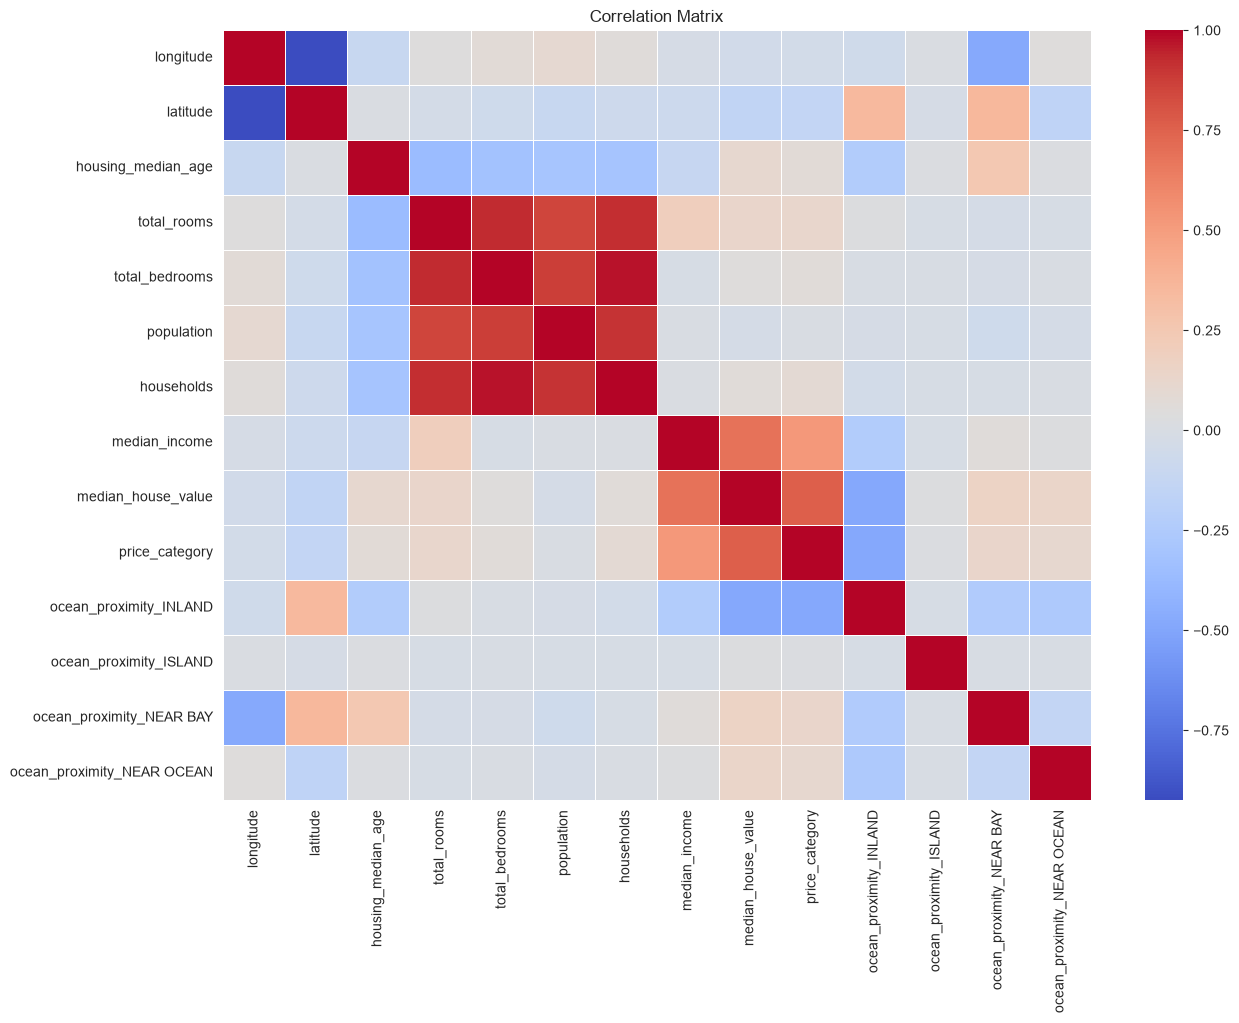

In [11]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


In [12]:
# checking how strongly median_income is related to the target
df['median_income'].corr(df['price_category']).round(4)


np.float64(0.5219)

As expected, `median_income` has a strong positive correlation with the price category, which makes sense because richer areas have more expensive houses.

## 9. Train Test Split

In [13]:
X = df.drop(['median_house_value', 'price_category'], axis=1)
y = df['price_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Training set:', X_train.shape)
print('Testing set :', X_test.shape)


Training set: (16512, 12)
Testing set : (4128, 12)


## 10. Feature Scaling

I scaled all the numeric features with StandardScaler so that the distance based algorithms like KNN and SVM work properly.

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print('Scaling done!')


Scaling done!


## 11. Training Different Classification Models

I trained the following classifiers and evaluated all of them on the test set:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Random Forest
5. Gradient Boosting
6. Linear SVM
7. Naive Bayes



In [15]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Linear SVM': LinearSVC(random_state=42),
    'Naive Bayes': GaussianNB()
}

results = []
fitted_models = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    fitted_models[name] = model
    predictions[name] = y_pred
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.893895,0.892048,0.896368,0.894203
1,Gradient Boosting,0.872093,0.869294,0.876029,0.872648
2,KNN,0.853440,0.860316,0.844068,0.852114
3,Decision Tree,0.850775,0.846817,0.856659,0.851709
4,Logistic Regression,0.838905,0.833016,0.847942,0.840413
5,Linear SVM,0.838421,0.829717,0.851816,0.840621
6,Naive Bayes,0.536822,0.963636,0.076998,0.142601


## 12. Visual Comparison of the Models

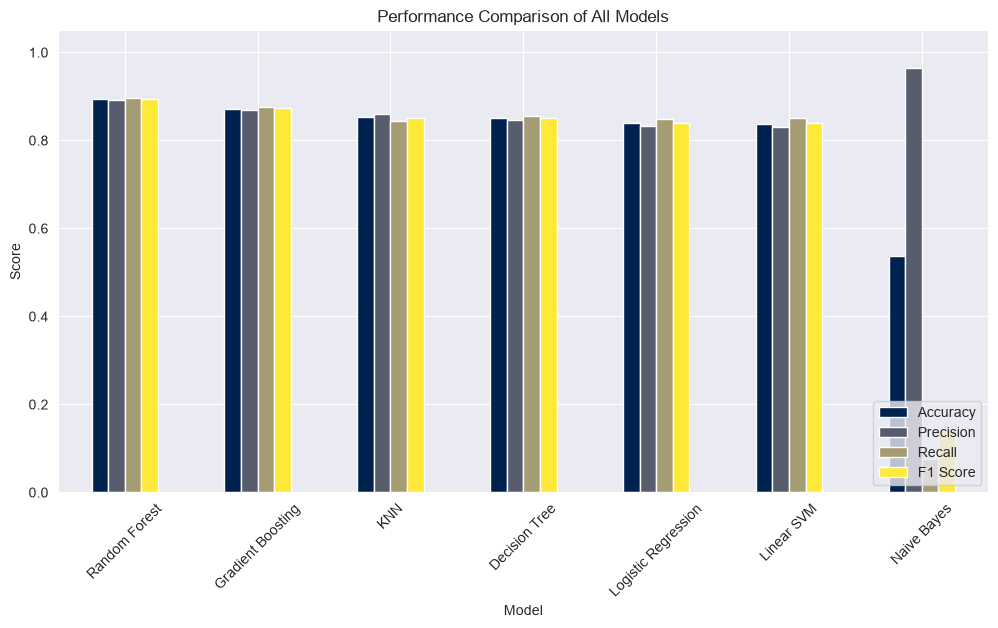

In [16]:
results_df.set_index('Model').plot(kind='bar', figsize=(12, 6), colormap='cividis')
plt.title('Performance Comparison of All Models')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.show()


## 13. Detailed Report of the Best Model

In [17]:
best_model_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]
y_pred_best = predictions[best_model_name]

print('Best model selected:', best_model_name)
print('Accuracy :', round(accuracy_score(y_test, y_pred_best), 4))
print('Precision:', round(precision_score(y_test, y_pred_best), 4))
print('Recall   :', round(recall_score(y_test, y_pred_best), 4))
print('F1 Score :', round(f1_score(y_test, y_pred_best), 4))


Best model selected: Random Forest
Accuracy : 0.8939
Precision: 0.892
Recall   : 0.8964
F1 Score : 0.8942


In [18]:
print(classification_report(y_test, y_pred_best))


              precision    recall  f1-score   support

           0       0.90      0.89      0.89      2063
           1       0.89      0.90      0.89      2065

    accuracy                           0.89      4128
   macro avg       0.89      0.89      0.89      4128
weighted avg       0.89      0.89      0.89      4128



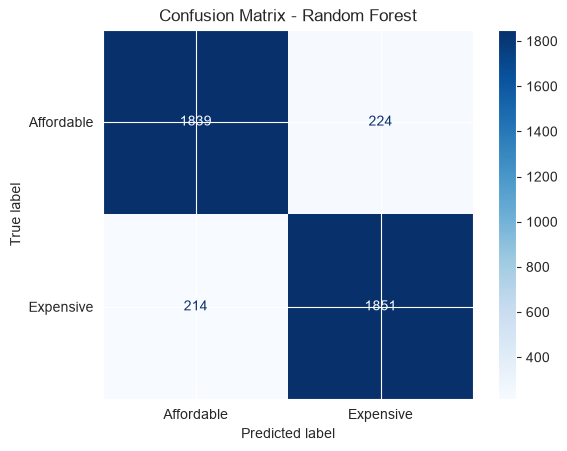

In [19]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Affordable', 'Expensive'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - ' + best_model_name)
plt.show()


## 14. Hyperparameter Tuning

Random Forest is a strong ensemble model, so I used GridSearchCV to find its optimal hyperparameters and try to improve the accuracy even more. Since the dataset is large I used only 3-fold cross validation to keep the runtime reasonable.

In [20]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid,
                           cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print('Best parameters:', grid_search.best_params_)
print('Best cross-validation accuracy:', round(grid_search.best_score_, 4))


Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation accuracy: 0.8874


## 15. Evaluating the Tuned Model

In [21]:
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)

print('Accuracy :', round(accuracy_score(y_test, y_pred_tuned), 4))
print('Precision:', round(precision_score(y_test, y_pred_tuned), 4))
print('Recall   :', round(recall_score(y_test, y_pred_tuned), 4))
print('F1 Score :', round(f1_score(y_test, y_pred_tuned), 4))
print()
print(classification_report(y_test, y_pred_tuned))


Accuracy : 0.8944
Precision: 0.8903
Recall   : 0.8998
F1 Score : 0.895

              precision    recall  f1-score   support

           0       0.90      0.89      0.89      2063
           1       0.89      0.90      0.89      2065

    accuracy                           0.89      4128
   macro avg       0.89      0.89      0.89      4128
weighted avg       0.89      0.89      0.89      4128



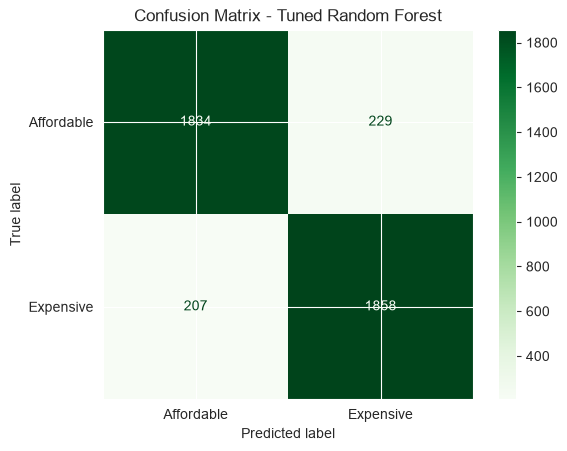

In [22]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Affordable', 'Expensive'])
disp.plot(cmap='Greens')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.show()


## 16. Performance Before and After Tuning

In [23]:
rf_default_pred = predictions['Random Forest']
comparison = pd.DataFrame({
    'Model': ['Random Forest (Default)', 'Random Forest (Tuned)'],
    'Accuracy': [accuracy_score(y_test, rf_default_pred), accuracy_score(y_test, y_pred_tuned)],
    'Precision': [precision_score(y_test, rf_default_pred), precision_score(y_test, y_pred_tuned)],
    'Recall': [recall_score(y_test, rf_default_pred), recall_score(y_test, y_pred_tuned)],
    'F1 Score': [f1_score(y_test, rf_default_pred), f1_score(y_test, y_pred_tuned)]
})
comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest (Default),0.893895,0.892048,0.896368,0.894203
1,Random Forest (Tuned),0.894380,0.890273,0.899758,0.894990


The improvement after tuning is very small because Random Forest was already performing very well on this dataset (around 0.89 accuracy).

## 17. Feature Importance

Finally, let me check which features the Random Forest model found the most useful.

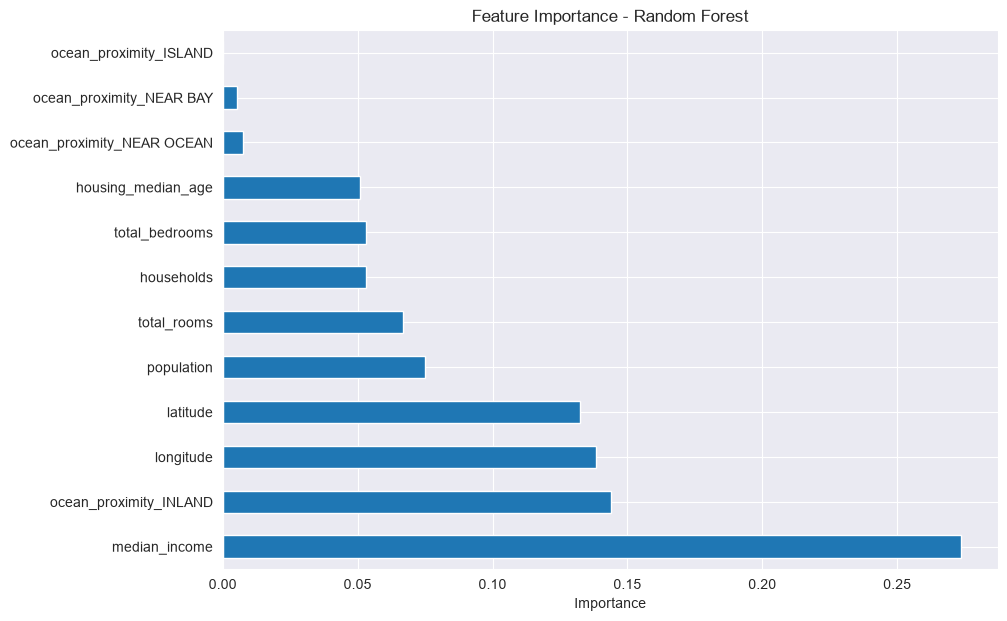

In [24]:
feature_names = X.columns if hasattr(X, 'columns') else None
feature_importance = pd.Series(tuned_model.feature_importances_, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(10, 7))
feature_importance.plot(kind='barh')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.show()


## Conclusion

I converted the California housing regression dataset into a binary classification problem by creating a `price_category` target. After imputing the missing values of `total_bedrooms`, one-hot encoding `ocean_proximity` and scaling the features, I trained 7 classifiers and compared their performance.

**Random Forest** performed the best with about **0.89 accuracy**, and after hyperparameter tuning with GridSearchCV it improved slightly further to **0.8944**. `median_income` turned out to be the most important feature, which matches real-world expectations.

